# Recipe Prediction & Inverse Formulation Design

**What this notebook does** (plant-based cheese formulation):

1. Trains *forward* surrogate models — formulation + process parameters → physical properties.
2. Ranks every measured property by out-of-sample predictability and **auto-selects the top-5 most predictable parameters** (you can override the selection).
3. Given **your target values** for those parameters, runs an *inverse* optimiser that outputs an **optimised recipe** (ingredient percentages + process parameters), plus alternative candidates.
4. **Cheese archetypes** (section 11): measured profiles of 258 commercial cheeses (cheddar, mozzarella, gouda, parmesan, ...) serve as quantitative "ideas" of cheese types — `design_for("MOZZA")` designs the closest plant-based match.

**Method provenance:** built on the state of the art surveyed in [research.md](research.md) — a two-stage *surrogate + optimiser* design, the field-standard approach for small noisy formulation datasets. Project-specific design notes: [PHASE1_RESEARCH_AND_DESIGN.md](PHASE1_RESEARCH_AND_DESIGN.md).

**Data privacy:** the notebook loads `Analysis_all&Ingredients&pH.xlsx` programmatically for training only. All printed output is **aggregate statistics** — raw recipe rows and individual measurement values are never displayed.

**Physical realism:** the optimiser uses the `Ingredient_info` spec sheet (state at room temperature + nutrient composition) and the measured **pH** data to keep designed recipes credible — liquid fraction and predicted pH are constrained to the ranges observed in comparable real recipes, and every ingredient-category share (Acid, Salt, Starch, ...) is capped at the maximum seen among those recipes.

**Environment:** run with the project virtualenv `.venv` (Python 3.12 — see `requirements.txt`).

## 1 — Setup & configuration

Key knobs:
- `MIN_FREQ` — an ingredient gets its own feature column only if it appears in at least this many recipes (rare one-off ingredients are folded into category totals instead — they have no predictive support on their own).
- `MIN_TARGET_TRIALS` — a property is only modelled if measured in at least this many trials.
- `SELECTED_PROPERTIES` — leave `None` to auto-select the top-5 most predictable properties, or set a list of property names (exact names from the ranking table in section 6) to override.

In [1]:
import os, warnings, hashlib, json
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"   # also silence joblib worker processes
import numpy as np
import pandas as pd
from pathlib import Path

RNG = 42
np.random.seed(RNG)

DATA = Path("Analysis_all&Ingredients&pH.xlsx")
assert DATA.exists(), "Run this notebook from the project root (folder containing Analysis_all&Ingredients&pH.xlsx)."

MIN_FREQ = 5             # ingredient must appear in >= this many recipes to get its own column
MIN_TARGET_TRIALS = 40   # only model properties measured in >= this many trials
N_SPLITS, N_REPEATS = 5, 2   # repeated GroupKFold

# --- USER OVERRIDE ------------------------------------------------------
# None  -> auto-select the 5 most predictable properties (section 7).
# Or:  SELECTED_PROPERTIES = ["<name>", ...]  using names from the section-6 table.
SELECTED_PROPERTIES = None
# Example override (uncomment and edit -- exact names from the section-6 ranking table):
# SELECTED_PROPERTIES = ["pH", "hardness", "Moisture", "max extensibility", "viscosity max"]

## 2 — Load data

Three sheets keyed by `Trial` — formulation (ingredient percentages), physical measurements (with replicates), process parameters — plus the `Ingredient_info` spec sheet (matched to formulations via `Product code/ name`): physical **state at room temperature** and **nutrient composition per 100 g**. Only aggregate counts are printed.

In [2]:
xl = pd.ExcelFile(DATA)
form = xl.parse("Formulation Data")
phys = xl.parse("Physical Data")
proc = xl.parse("Process Data")
info = xl.parse("Ingredient_info")

form["Ingredient_Name"] = form["Ingredient_Name"].astype(str).str.strip()
form["Ingredient_Category"] = form["Ingredient_Category"].astype(str).str.strip()
phys["Parameter"] = phys["Parameter"].astype(str).str.strip()
phys["Analysis"] = phys["Analysis"].astype(str).str.strip()

# ingredient spec table keyed by normalised name (matches Formulation Ingredient_Name)
info.columns = [str(c).replace("\n", " ").strip() for c in info.columns]
_norm = lambda s: str(s).strip().lower()
info["key"] = info["Product code/ name"].map(_norm)
spec = info.drop_duplicates("key").set_index("key")
STATE_KEYS = ["liquid", "powder", "solid", "paste"]
state = (spec["State at room temperature"].astype(str).str.strip().str.lower()
         .where(lambda s: s.isin(STATE_KEYS)))
NUTR_MAP = {"nutr__energy": "Energy   (kJ/100 g)",
            "nutr__fat": "Fat (g/100 g)",
            "nutr__satfat": "Fat of wich saturates  (g/100 g)",
            "nutr__carb": "Carbohydrate (g/100 g)",
            "nutr__sugar": "Carbohydrate of which sugar   (g/100 g)",
            "nutr__fibre": "Fibre   (g/100 g)",
            "nutr__protein": "Protein   (g/100 g)",
            "nutr__salt": "Salt   (g/100 g)"}
nutr_tab = pd.DataFrame({k: pd.to_numeric(spec[v], errors="coerce") for k, v in NUTR_MAP.items()})

print(f"Formulation rows: {len(form):6,}  | trials: {form['Trial'].nunique():,}")
print(f"Physical rows:    {len(phys):6,}  | trials: {phys['Trial'].nunique():,}")
print(f"Process rows:     {len(proc):6,}  | trials: {proc['Trial'].nunique():,}")
print(f"Ingredient specs: {len(spec):6,}  | state known: {state.notna().sum():,}")

Formulation rows: 11,898  | trials: 1,204
Physical rows:    54,275  | trials: 702
Process rows:      4,151  | trials: 1,120
Ingredient specs:    310  | state known: 289


## 3 — Hybrid featurisation

Lessons from the previous modelling attempt (and confirmed by the literature in research.md §2):

- **Rare ingredients hurt** — most ingredients appear in only 1–2 test recipes and carry no learnable signal. Only ingredients used in ≥ `MIN_FREQ` recipes get individual `%` columns.
- **Pure category grouping is lossy** (e.g. starches differ a lot), so we keep **both**: individual columns for common ingredients **and** 13 category-mass totals (which also absorb the rare ingredients).
- Plus: ingredient count, and standardised **process parameters** (temperature, duration, speed/agitator summaries). Process *steps* are non-standardised, so only numeric summaries are used.
- **Spec-derived features** (from `Ingredient_info`): per-recipe **physical-state fractions** (liquid / powder / solid / paste mass shares) and the **mixed nutrient composition** (fat, protein, carbs, salt, ... per 100 g, linearly mixed from ingredient specs). These describe any recipe physically — including ones built from rare ingredients.

In [3]:
ing_wide = form.pivot_table(index="Trial", columns="Ingredient_Name",
                            values="Ingredient_percentage", aggfunc="sum", fill_value=0.0)
freq = (ing_wide > 0).sum(axis=0)
common = freq[freq >= MIN_FREQ].index.tolist()
print(f"ingredients total={ing_wide.shape[1]}  with own column (>= {MIN_FREQ} recipes): {len(common)}")

ing_common = ing_wide[common].add_prefix("ing__")

cat_sums = form.pivot_table(index="Trial", columns="Ingredient_Category",
                            values="Ingredient_percentage", aggfunc="sum", fill_value=0.0)
cat_sums = cat_sums.add_prefix("cat__")

n_ing = (ing_wide > 0).sum(axis=1).rename("n_ingredients")

ing2cat = (form.drop_duplicates("Ingredient_Name")
           .set_index("Ingredient_Name")["Ingredient_Category"].to_dict())

proc_feat = proc.groupby("Trial").agg(
    proc__temp_max=("Temperature", "max"),
    proc__temp_mean=("Temperature", "mean"),
    proc__dur_total=("Duration_Minutes", "sum"),
    proc__speed_max=("Speed", "max"),
    proc__agit_max=("Speed_Agitator", "max"),
    proc__n_steps=("Step_Number", "max"),
)

# --- spec-derived features: state fractions + mixed nutrient composition ---
all_ings = ing_wide.columns.tolist()
ing_state = pd.Series([state.get(_norm(i), np.nan) for i in all_ings], index=all_ings)
ING_STATE = {i: (s if isinstance(s, str) else "unknown") for i, s in ing_state.items()}

state_feat = pd.DataFrame(index=ing_wide.index)
for s in STATE_KEYS:
    cols = ing_state[ing_state == s].index
    state_feat[f"state__{s}"] = ing_wide[cols].sum(axis=1) if len(cols) else 0.0
state_feat["state__unknown"] = ing_wide[ing_state[ing_state.isna()].index].sum(axis=1)

ing_nutr = pd.DataFrame({k: [nutr_tab[k].get(_norm(i), np.nan) for i in all_ings]
                         for k in NUTR_MAP}, index=all_ings)
NUTR_MED = {k: float(np.nansum(ing_nutr[k] * freq) / freq[ing_nutr[k].notna()].sum())
            for k in NUTR_MAP}   # usage-weighted fallback for missing specs
nutr_feat = pd.DataFrame(index=ing_wide.index)
for k in NUTR_MAP:
    vals = ing_nutr[k]
    known = vals.notna()
    contrib = ing_wide[vals.index[known]].mul(vals[known].values, axis=1).sum(axis=1)
    share = ing_wide[vals.index[known]].sum(axis=1)
    nutr_feat[k] = np.where(share > 0.5, contrib / share, np.nan)

X_all = (ing_common.join(cat_sums, how="outer").join(n_ing, how="outer")
         .join(proc_feat, how="outer").join(state_feat, how="outer")
         .join(nutr_feat, how="outer"))
FEAT_COLS = list(X_all.columns)

liquid_frac_real = state_feat["state__liquid"]
LIQ_P5, LIQ_P95 = float(liquid_frac_real.quantile(.05)), float(liquid_frac_real.quantile(.95))
print(f"state known for {(~ing_state.isna()).sum()}/{len(all_ings)} used ingredients")
print(f"real-recipe liquid fraction: p5={LIQ_P5:.2f}  median={liquid_frac_real.median():.2f}  p95={LIQ_P95:.2f}")
print(f"feature matrix X_all: {X_all.shape[0]} trials x {X_all.shape[1]} features")

ingredients total=172  with own column (>= 5 recipes): 82
state known for 153/172 used ingredients
real-recipe liquid fraction: p5=0.37  median=0.51  p95=0.75
feature matrix X_all: 1204 trials x 115 features


## 4 — Targets & the noise ceiling

The same recipe can yield different measurements (human / machine variation), so before judging any model we estimate **how much variance is even explainable**. From replicate measurements we compute an ICC-style ceiling per property:

$$R^2_{ceiling} = \frac{\sigma^2_{between}}{\sigma^2_{between} + \sigma^2_{within}}$$

A model's CV R² should be read **relative to this ceiling** (research.md §3). Texturometer data is restricted to `BLOCK` measurements to avoid mixing measurement geometries; replicates are aggregated by **median** per (trial, parameter).

**pH** (measured per trial, `Nutritional data` sheet) joins the target table as a property like any other — it is benchmarked, can be a design target, and additionally powers a pH-realism constraint in the optimiser (section 8). It has no replicate-based noise ceiling.

In [4]:
is_tex = phys["Analysis"] == "Texturometer"
phys_use = pd.concat([
    phys[~is_tex],
    phys[is_tex & (phys["Texture_Analysis_Type"].astype(str) == "BLOCK")],
], ignore_index=True)

# per-(trial, parameter) median = modelling target
tgt_med = phys_use.groupby(["Trial", "Parameter"])["Value"].median().unstack("Parameter")

noise_rows = []
for param, g in phys_use.groupby("Parameter"):
    per_trial = g.groupby("Trial")["Value"]
    within = per_trial.var(ddof=1).dropna()          # trials with >= 2 replicates
    if len(within) < 3:
        continue
    sigma2_within = within.mean()
    trial_means = per_trial.median()
    sigma2_between = trial_means.var(ddof=1)
    total = sigma2_between + sigma2_within
    icc = sigma2_between / total if total > 0 else np.nan
    noise_rows.append({"Parameter": param, "n_trials": int(trial_means.shape[0]),
                       "n_trials_with_reps": int(len(within)),
                       "R2_ceiling_icc": icc})
noise = (pd.DataFrame(noise_rows).set_index("Parameter")
         .sort_values("R2_ceiling_icc", ascending=False))

# pH: measured per trial in the Nutritional data sheet
nut = xl.parse("Nutritional data")
ph_series = pd.to_numeric(nut.set_index("TRIAL")["pH"], errors="coerce").dropna()
tgt_med = tgt_med.join(ph_series.rename("pH"), how="outer")
print(f"pH measured for {len(ph_series):,} trials "
      f"(p5={ph_series.quantile(.05):.2f}  median={ph_series.median():.2f}  p95={ph_series.quantile(.95):.2f})")

print("Noise ceiling per parameter (max achievable R2 for a single measurement):")
display(noise.round(3))

pH measured for 859 trials (p5=3.55  median=4.23  p95=5.85)
Noise ceiling per parameter (max achievable R2 for a single measurement):


,n_trials,n_trials_with_reps,R2_ceiling_icc
Parameter,,,
Moisture,245,234,0.989
oiling,606,602,0.973
hardness,552,551,0.961
viscosity max,382,366,0.950
average viscosity,382,366,0.939
max extensibility,382,366,0.905
melting,613,609,0.897
viscosity min,382,366,0.893
average extensibility,382,366,0.874


## 5 — Leakage-safe cross-validation groups

Many trials are **exact duplicate recipes** (replicated batches). Random CV would put copies of the same recipe in train *and* test and inflate scores (research.md §4). We fingerprint each recipe's ingredient vector and use **GroupKFold** on the fingerprint, so a recipe never appears on both sides of a split.

In [5]:
def fingerprint(row):
    v = np.round(row.values.astype(float), 4)
    return hashlib.md5(v.tobytes()).hexdigest()[:12]

fp = ing_wide.apply(fingerprint, axis=1).rename("fp")
print(f"unique recipes: {fp.nunique()} of {len(fp)} trials")

unique recipes: 719 of 1204 trials


## 6 — Forward-model benchmark

Six model families suited to small noisy tabular data (research.md §1) — regularised linear (ElasticNet), bagged trees (RandomForest, ExtraTrees) and gradient boosting (HistGBR, XGBoost, LightGBM) — evaluated per property with **repeated GroupKFold**. If [TabPFN](https://github.com/PriorLabs/TabPFN) is installed it joins the benchmark automatically (optional; `pip install tabpfn`).

The best model per property is kept; properties are then ranked by CV R².

In [6]:
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")   # re-assert: library imports can reset filters

try:
    from tabpfn import TabPFNRegressor
    HAS_TABPFN = True
except Exception:
    HAS_TABPFN = False
print("TabPFN available:", HAS_TABPFN)

def make_models():
    models = {
        "ElasticNet": Pipeline([("imp", SimpleImputer(strategy="median")),
                                 ("sc", StandardScaler()),
                                 ("m", ElasticNetCV(l1_ratio=[.1, .5, .9, 1.0], alphas=50,
                                                    cv=3, random_state=RNG, max_iter=5000))]),
        "RandomForest": Pipeline([("imp", SimpleImputer(strategy="median")),
                                   ("m", RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                                               n_jobs=-1, random_state=RNG))]),
        "ExtraTrees": Pipeline([("imp", SimpleImputer(strategy="median")),
                                 ("m", ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2,
                                                           n_jobs=-1, random_state=RNG))]),
        "HistGBR": Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("m", HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05,
                                                                  max_iter=400, l2_regularization=1.0,
                                                                  random_state=RNG))]),
        "XGBoost": Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("m", xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                                     subsample=0.8, colsample_bytree=0.8,
                                                     reg_lambda=2.0, min_child_weight=5,
                                                     n_jobs=-1, random_state=RNG, verbosity=0))]),
        "LightGBM": Pipeline([("imp", SimpleImputer(strategy="median")),
                               ("m", lgb.LGBMRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                                       subsample=0.8, colsample_bytree=0.8,
                                                       reg_lambda=2.0, min_child_samples=10,
                                                       n_jobs=-1, random_state=RNG, verbose=-1))]),
    }
    if HAS_TABPFN:
        models["TabPFN"] = Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("m", TabPFNRegressor())])
    return models

def cv_eval(X, y, groups, n_splits=N_SPLITS, n_repeats=N_REPEATS):
    """Repeated GroupKFold; returns {model: (r2_mean, rmse_mean, mae_mean)}."""
    ng = groups.nunique()
    n_splits = min(n_splits, ng)
    out = {}
    for name in make_models():
        r2s, rmses, maes = [], [], []
        for rep in range(n_repeats):
            gkf = GroupKFold(n_splits=n_splits)
            rs = np.random.RandomState(RNG + rep)
            perm = rs.permutation(np.arange(len(X)))
            Xp, yp, gp = X.iloc[perm], y.iloc[perm], groups.iloc[perm]
            for tr, te in gkf.split(Xp, yp, gp):
                mdl = make_models()[name]
                mdl.fit(Xp.iloc[tr], yp.iloc[tr])
                pred = mdl.predict(Xp.iloc[te])
                if len(np.unique(yp.iloc[te])) < 2:
                    continue
                r2s.append(r2_score(yp.iloc[te], pred))
                rmses.append(np.sqrt(mean_squared_error(yp.iloc[te], pred)))
                maes.append(mean_absolute_error(yp.iloc[te], pred))
        out[name] = (np.mean(r2s) if r2s else np.nan,
                     np.mean(rmses) if rmses else np.nan,
                     np.mean(maes) if maes else np.nan)
    return out

TabPFN available: False


In [7]:
results = []
target_params = [p for p in tgt_med.columns
                 if tgt_med[p].notna().sum() >= MIN_TARGET_TRIALS]
print(f"Benchmarking {len(target_params)} properties measured in >= {MIN_TARGET_TRIALS} trials "
      f"(takes several minutes)...")

best_model_per_target = {}
for param in target_params:
    y = tgt_med[param].dropna()
    idx = y.index.intersection(X_all.index)
    y = y.loc[idx]
    X = X_all.loc[idx]
    g = fp.loc[idx]
    res = cv_eval(X, y, g)
    best = max(res, key=lambda k: (res[k][0] if not np.isnan(res[k][0]) else -1e9))
    best_model_per_target[param] = best
    row = {"Parameter": param, "n": len(idx), "best_model": best,
           "R2": res[best][0], "RMSE": res[best][1], "MAE": res[best][2]}
    for m in res:
        row[f"R2_{m}"] = res[m][0]
    results.append(row)
    print(f"  {param:38s} n={len(idx):4d}  best={best:12s}  R2={res[best][0]:.3f}")

resdf = pd.DataFrame(results).set_index("Parameter")
resdf = resdf.join(noise["R2_ceiling_icc"])
resdf["R2_vs_ceiling"] = resdf["R2"] / resdf["R2_ceiling_icc"]
resdf = resdf.sort_values("R2", ascending=False)
print("\nPredictability ranking (GroupKFold CV, best model per property):")
display(resdf[["n", "best_model", "R2", "RMSE", "MAE", "R2_ceiling_icc", "R2_vs_ceiling"]].round(3))

Benchmarking 21 properties measured in >= 40 trials (takes several minutes)...


  Fat                                    n= 185  best=RandomForest  R2=0.520


  Moisture                               n= 186  best=RandomForest  R2=0.729


  adhesiveness                           n= 494  best=ExtraTrees    R2=0.160


  average extensibility                  n= 313  best=ElasticNet    R2=0.585


...

  springiness                            n= 494  best=RandomForest  R2=0.217


  viscosity max                          n= 313  best=ExtraTrees    R2=0.664


  viscosity min                          n= 313  best=ExtraTrees    R2=0.505


  pH                                     n= 859  best=XGBoost       R2=0.849

Predictability ranking (GroupKFold CV, best model per property):


,n,best_model,R2,RMSE,MAE,R2_ceiling_icc,R2_vs_ceiling
Parameter,,,,,,,
pH,859,XGBoost,0.849,0.268,0.166,NaN,NaN
hardness,494,ExtraTrees,0.744,1292.783,886.066,0.961,0.774
Moisture,186,RandomForest,0.729,2.911,1.739,0.989,0.737
max extensibility,313,ElasticNet,0.719,13.696,7.866,0.905,0.795
gumminess,494,ExtraTrees,0.697,24187.061,16745.896,0.833,0.838
viscosity max,313,ExtraTrees,0.664,8998018.531,5327191.563,0.950,0.699
average viscosity,313,ExtraTrees,0.640,4802182.647,2880977.223,0.939,0.681
melted adhesiveness,305,ElasticNet,0.618,80.434,56.427,0.861,0.719
average extensibility,313,ElasticNet,0.585,0.106,0.069,0.874,0.670


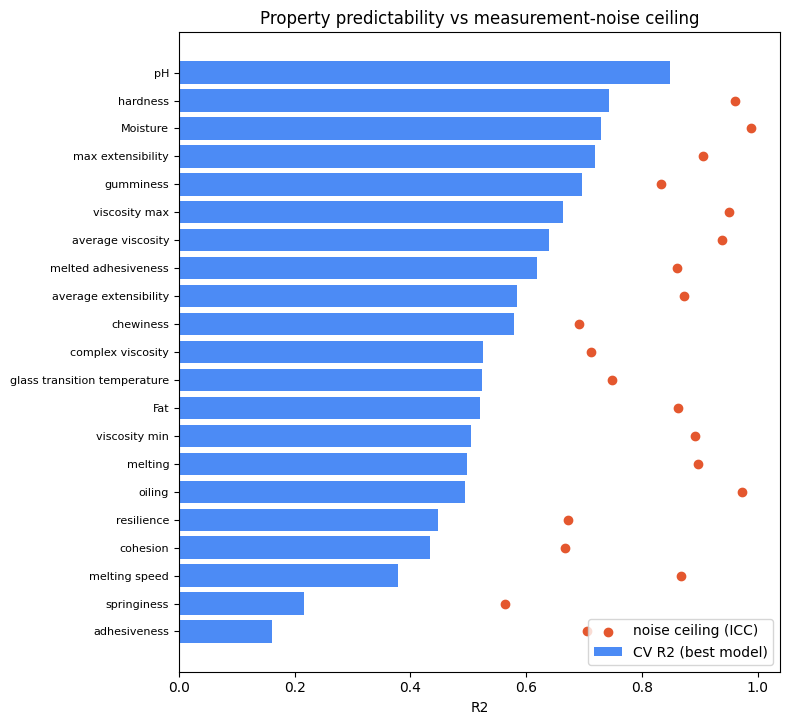

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(resdf))))
ax.barh(range(len(resdf)), resdf["R2"].iloc[::-1], color="#4C8BF5", label="CV R2 (best model)")
ax.scatter(resdf["R2_ceiling_icc"].iloc[::-1], range(len(resdf)),
           color="#E4572E", zorder=3, label="noise ceiling (ICC)")
ax.set_yticks(range(len(resdf)))
ax.set_yticklabels(resdf.index[::-1], fontsize=8)
ax.set_xlabel("R2")
ax.set_title("Property predictability vs measurement-noise ceiling")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7 — Select properties & train final models

By default the **top-5 by CV R²** are selected. To override, set `SELECTED_PROPERTIES` in section 1 and re-run from there. Final models (best family per property) are refit on **all** available data, and the observed value ranges are printed — use these when choosing target values in section 10.

In [9]:
if SELECTED_PROPERTIES:
    top5 = list(SELECTED_PROPERTIES)
    missing = [p for p in top5 if p not in resdf.index]
    assert not missing, f"Unknown property names: {missing} - use names from the section-6 table"
else:
    top5 = resdf.head(5).index.tolist()

print("Selected properties:")
final_models, target_stats = {}, {}
for param in top5:
    y = tgt_med[param].dropna()
    idx = y.index.intersection(X_all.index)
    y = y.loc[idx]
    X = X_all.loc[idx]
    mdl = make_models()[best_model_per_target[param]]
    mdl.fit(X, y)
    final_models[param] = mdl
    target_stats[param] = {"min": float(y.min()), "max": float(y.max()),
                           "median": float(y.median()), "mean": float(y.mean())}
    s = target_stats[param]
    print(f"  {param:38s} model={best_model_per_target[param]:12s} "
          f"range=[{s['min']:.3f} .. {s['max']:.3f}]  median={s['median']:.3f}")

Selected properties:


  pH                                     model=XGBoost      range=[2.020 .. 7.570]  median=4.230


  hardness                               model=ExtraTrees   range=[45.935 .. 15409.440]  median=3998.025


  Moisture                               model=RandomForest range=[34.560 .. 72.890]  median=52.235


  max extensibility                      model=ElasticNet   range=[0.160 .. 247.000]  median=7.250


  gumminess                              model=ExtraTrees   range=[149.295 .. 296138.680]  median=61632.467


In [10]:
def top_features(pipe, k=10):
    m = pipe.named_steps["m"]
    if hasattr(m, "feature_importances_"):
        vals = np.asarray(m.feature_importances_)
    elif hasattr(m, "coef_"):
        vals = np.abs(np.asarray(m.coef_))
    else:
        return None
    if len(vals) != len(FEAT_COLS):
        return None
    return pd.Series(vals, index=FEAT_COLS).sort_values(ascending=False).head(k)

for p in top5:
    tf = top_features(final_models[p])
    if tf is None:
        print(f"\n[{p}] ({best_model_per_target[p]}) - no per-feature importances available")
        continue
    print(f"\n[{p}] top feature drivers ({best_model_per_target[p]}):")
    for name, v in tf.items():
        print(f"   {name:42s} {v:.4f}")


[pH] top feature drivers (XGBoost):
   cat__Protein                               0.2281
   cat__Colour                                0.0631
   cat__Acid                                  0.0618
   ing__Lactic acid anhydrous / SpecialIngredients 0.0508
   nutr__protein                              0.0490
   n_ingredients                              0.0473
   ing__4474806/ BiOrigins - Citric acid      0.0437
   ing__L6661/ Lactic acid 80%                0.0363
   cat__Flavour                               0.0362
   ing__Salt                                  0.0301

[hardness] top feature drivers (ExtraTrees):
   ing__CF77/ KMC Starch CF77                 0.2037
   state__liquid                              0.1287
   cat__Starch                                0.0942
   state__powder                              0.0748
   cat__Water                                 0.0640
   nutr__carb                                 0.0607
   ing__Water                                 0.0600
   ing__Sal


[Moisture] top feature drivers (RandomForest):
   state__liquid                              0.6292
   ing__CF77/ KMC Starch CF77                 0.0973
   cat__Water                                 0.0561
   ing__Salt                                  0.0356
   nutr__energy                               0.0206
   cat__Starch                                0.0180
   ing__CF30/ KMC Starch                      0.0176
   cat__Salt                                  0.0122
   cat__Acid                                  0.0106
   state__powder                              0.0093

[max extensibility] top feature drivers (ElasticNet):
   ing__Rennet Casein 90 Mesh (concentrate)   5.9718
   ing__Butter oil - Anhydrous milk fat (AMF) / ORGANIC GHEE 5.3055
   ing__CARRAGEENAN KAPPA (E407) / Special Ingredients 3.7062
   state__solid                               2.5791
   cat__Additive                              2.1893
   proc__dur_total                            1.3095
   ing__CF66/ KMC Starch 

## 8 — Inverse design: from target properties to an optimised recipe

Given target values for the selected properties, `design_recipe`:

1. **Warm start** — finds the `n_neighbors` real trials closest to the targets in (standardised) property space; their ingredients define a **realistic palette**, their process settings define the process bounds, and **their recipes seed the optimiser's start population** — the search starts from physically valid, in-band recipes and only refines toward the targets.
2. **Optimises** with `scipy.optimize.differential_evolution` (vectorised — whole populations are scored with batched model predictions). Ingredient weights are normalised to **sum to 100%** inside the objective (normalisation repair, research.md §5); each property's error is measured in units of its **spread across trials (IQR)** — robust even when targets sit at the edge of the observed range — plus a realism penalty on ingredients exceeding 1.5× their maximum observed share. Recipe complexity is capped structurally: only the largest `max_ingredients` weights survive (default = typical ingredient count of the neighbour recipes + 2), so candidates stay as simple as real recipes — this also keeps the `n_ingredients` feature inside the training distribution.
3. **Mixability constraint** — the candidate's **liquid mass fraction** (from the `Ingredient_info` state column) is strongly penalised if it leaves the range observed among the neighbour recipes, so the optimiser cannot propose an unmixable powder-heavy blend. Each candidate's liquid/powder split is reported.
4. **Category caps** — each ingredient-category share (Acid, Salt, Starch, ...) is capped at the **maximum seen among the neighbour recipes, clipped by the global 99th percentile** so extreme one-off test recipes cannot loosen the cap. This is what stops e.g. a 10% acid dose when real comparable recipes never exceed ~1%.
5. **pH realism** — a dedicated pH model (trained on the measured trial pH values) predicts each candidate's pH, which is penalised outside the neighbours' measured pH range (clipped to the global p5–p95). The estimated pH is reported per candidate.
6. **Multi-restart + dedupe** — several independent runs, sorted by objective, deduplicated by ingredient set, returning the best recipe and a few alternatives.

In [11]:
from scipy.optimize import differential_evolution
from sklearn.neighbors import NearestNeighbors

COLPOS = {c: i for i, c in enumerate(FEAT_COLS)}
PROC_DEFAULTS = X_all[[c for c in FEAT_COLS if c.startswith("proc__")]].median()
obs_max = ing_wide[common].max()   # realism bound: max observed share per ingredient

def nutr_of(ing, k):
    """Nutrient value per 100 g for an ingredient; usage-weighted median if unknown."""
    v = nutr_tab[k].get(_norm(ing), np.nan)
    return float(v) if np.isfinite(v) else NUTR_MED[k]

def build_feature_row(frac: dict, proc_vals: dict):
    """frac: {ingredient: fraction summing to 1}; proc_vals: {proc col: value} -> aligned Series."""
    row = pd.Series(0.0, index=FEAT_COLS)
    catacc = {}
    stacc = {s: 0.0 for s in STATE_KEYS + ["unknown"]}
    nuacc = {k: 0.0 for k in NUTR_MAP}
    for ing, f in frac.items():
        col = f"ing__{ing}"
        if col in row.index:
            row[col] = f
        cat = ing2cat.get(ing)
        if cat is not None:
            catacc[cat] = catacc.get(cat, 0.0) + f
        stacc[ING_STATE.get(ing, "unknown")] += f
        for k in NUTR_MAP:
            nuacc[k] += f * nutr_of(ing, k)
    for cat, s in catacc.items():
        c = f"cat__{cat}"
        if c in row.index:
            row[c] = s
    for s, v in stacc.items():
        row[f"state__{s}"] = v
    for k, v in nuacc.items():
        row[k] = v
    row["n_ingredients"] = float(sum(1 for v in frac.values() if v > 1e-4))
    for c in FEAT_COLS:
        if c.startswith("proc__"):
            row[c] = proc_vals.get(c, PROC_DEFAULTS[c])
    return row

# pH-realism model for the optimiser (independent of whether pH is a design target)
if "pH" in tgt_med.columns:
    _yph = tgt_med["pH"].dropna()
    _idxp = _yph.index.intersection(X_all.index)
    PH_MODEL = make_models()["LightGBM"]
    PH_MODEL.fit(X_all.loc[_idxp], _yph.loc[_idxp])
    PH_GLOBAL = (float(_yph.quantile(.05)), float(_yph.quantile(.95)))
    print(f"pH-realism model trained on {len(_idxp)} trials")
else:
    PH_MODEL, PH_GLOBAL = None, (None, None)

pH-realism model trained on 859 trials


In [12]:
import io, contextlib

def design_recipe(targets: dict, weights=None, n_neighbors=30, n_restarts=6,
                  maxiter=200, n_alternatives=2, max_ingredients=None):
    """Inverse design: targets {property: value} -> list of candidate recipes.
    max_ingredients caps recipe complexity (default: typical count of comparable
    real recipes + 2)."""
    warnings.filterwarnings("ignore")   # re-assert: some libs reset filters
    props = list(targets.keys())
    if weights is None:
        weights = {p: 1.0 for p in props}

    # 1) nearest real trials in standardised target-property space
    T = tgt_med[props].dropna()
    idx = T.index.intersection(X_all.index)
    T = T.loc[idx]
    mu, sd = T.mean(), T.std().replace(0, 1)
    Tz = (T - mu) / sd
    qz = (pd.Series(targets) - mu) / sd
    nn = NearestNeighbors(n_neighbors=min(n_neighbors, len(Tz))).fit(Tz.values)
    dist, nbr = nn.kneighbors(qz.values.reshape(1, -1))
    nbr_trials = Tz.index[nbr[0]]

    # realistic palette = common ingredients used by the neighbours
    pal = [c.replace("ing__", "") for c in ing_common.columns
           if (ing_wide.loc[nbr_trials, c.replace("ing__", "")] > 0).any()]
    if len(pal) < 3:
        pal = common[:20]

    # process bounds from the neighbours
    pf = proc_feat.reindex(nbr_trials)
    proc_cols = [c for c in FEAT_COLS if c.startswith("proc__")]
    proc_lo, proc_hi = pf.min(), pf.max()

    n_ing, n_proc = len(pal), len(proc_cols)
    bounds = [(0.0, 1.0)] * n_ing
    for c in proc_cols:
        lo, hi = proc_lo.get(c), proc_hi.get(c)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = PROC_DEFAULTS[c] * 0.8, PROC_DEFAULTS[c] * 1.2 + 1e-6
        bounds.append((float(lo), float(hi)))

    pal_obs_max = np.array([obs_max.get(p, 1.0) for p in pal])
    pal_ing_pos = [COLPOS.get(f"ing__{p}") for p in pal]
    pal_cat_groups = {}
    for i, p in enumerate(pal):
        cat = ing2cat.get(p)
        if cat is not None and f"cat__{cat}" in COLPOS:
            pal_cat_groups.setdefault(f"cat__{cat}", []).append(i)
    proc_pos = [COLPOS[c] for c in proc_cols]
    typical_n = float((ing_wide.loc[nbr_trials] > 0).sum(axis=1).median())
    K = max_ingredients if max_ingredients is not None else int(typical_n) + 2
    K = min(K, n_ing)

    # spec wiring: per-palette state one-hots + nutrient vectors
    st_vec = np.zeros((len(STATE_KEYS) + 1, n_ing))
    for i, p in enumerate(pal):
        s = ING_STATE.get(p, "unknown")
        st_vec[(STATE_KEYS.index(s) if s in STATE_KEYS else len(STATE_KEYS)), i] = 1.0
    nu_vec = np.array([[nutr_of(p, k) for p in pal] for k in NUTR_MAP])
    state_pos = [COLPOS[f"state__{s}"] for s in STATE_KEYS] + [COLPOS["state__unknown"]]
    nutr_pos = [COLPOS[k] for k in NUTR_MAP]
    # mixability band: liquid fraction range among the neighbour recipes
    nb_liq = liquid_frac_real.reindex(nbr_trials).dropna()
    liq_lo, liq_hi = float(nb_liq.min()), float(nb_liq.max())
    liq_row = st_vec[STATE_KEYS.index("liquid"), :]
    # category caps: neighbours' max, clipped by the global p99 (extreme one-off
    # test recipes must not loosen the cap)
    cat_cols = [c for c in FEAT_COLS if c.startswith("cat__")]
    cat_pos = [COLPOS[c] for c in cat_cols]
    nbC = cat_sums.reindex(nbr_trials)[cat_cols]
    cat_hi = np.minimum(nbC.max().values, cat_sums[cat_cols].quantile(0.99).values)
    # pH band from the neighbours' measured pH, clipped to the global p5-p95
    if PH_MODEL is not None:
        nb_ph = ph_series.reindex(nbr_trials).dropna()
        if len(nb_ph) >= 5:
            ph_lo = max(float(nb_ph.min()), PH_GLOBAL[0])
            ph_hi = min(float(nb_ph.max()), PH_GLOBAL[1])
            if ph_lo > ph_hi:
                ph_lo, ph_hi = PH_GLOBAL
        else:
            ph_lo, ph_hi = PH_GLOBAL
    else:
        ph_lo, ph_hi = None, None
    # per-property error scale: IQR across trials (robust for edge-of-range targets)
    SCALES = {p: float(max(tgt_med[p].quantile(.75) - tgt_med[p].quantile(.25), 1e-9))
              for p in props}

    def decode(x):
        w = np.clip(x[:n_ing], 0, None)
        if n_ing > K:                       # keep only the K largest weights
            thr = np.partition(w, -K)[-K]
            w = np.where(w >= thr, w, 0.0)
        s = w.sum()
        f = w / s if s > 0 else np.ones(n_ing) / n_ing
        frac = {pal[i]: f[i] for i in range(n_ing)}
        pv = {proc_cols[j]: x[n_ing + j] for j in range(n_proc)}
        return frac, pv, f

    def objective(x):
        """Vectorised: x is (n_params, S) from DE, or (n_params,) from the polish step."""
        single = (x.ndim == 1)
        X = x.reshape(-1, 1) if single else x
        S = X.shape[1]
        W = np.clip(X[:n_ing, :], 0, None)
        if n_ing > K:                                 # top-K sparsity projection
            thr = np.partition(W, -K, axis=0)[-K, :]
            W = np.where(W >= thr, W, 0.0)
        ssum = W.sum(axis=0)
        ssum = np.where(ssum > 0, ssum, 1.0)
        F = W / ssum                                  # fractions, sum-to-1 repair
        M = np.zeros((S, len(FEAT_COLS)))
        for i, j in enumerate(pal_ing_pos):
            if j is not None:
                M[:, j] = F[i, :]
        for catcol, idxs in pal_cat_groups.items():
            M[:, COLPOS[catcol]] = F[idxs, :].sum(axis=0)
        M[:, COLPOS["n_ingredients"]] = (F > 1e-4).sum(axis=0)
        for jj, j in enumerate(proc_pos):
            M[:, j] = X[n_ing + jj, :]
        SF = st_vec @ F                               # state fractions
        for k_i, j in enumerate(state_pos):
            M[:, j] = SF[k_i, :]
        NF = nu_vec @ F                               # mixed nutrient composition
        for k_i, j in enumerate(nutr_pos):
            M[:, j] = NF[k_i, :]
        dfM = pd.DataFrame(M, columns=FEAT_COLS)
        err = np.zeros(S)
        for p in props:
            pred = np.asarray(final_models[p].predict(dfM), dtype=float)
            err += weights[p] * np.abs(pred - targets[p]) / SCALES[p]
        over = np.maximum(0, F - 1.5 * pal_obs_max[:, None])   # realism penalty
        err += 5.0 * over.sum(axis=0)
        liq = liq_row @ F                                      # mixability constraint
        err += 20.0 * (np.maximum(0, liq_lo - liq) + np.maximum(0, liq - liq_hi))
        CC = M[:, cat_pos]                                     # category caps (upper only:
        err += 200.0 * np.maximum(0, CC - cat_hi[None, :]).sum(axis=1)  # excess is the failure mode)
        if PH_MODEL is not None:                               # pH realism
            ph_pred = np.asarray(PH_MODEL.predict(dfM), dtype=float)
            err += 20.0 * (np.maximum(0, ph_lo - ph_pred) + np.maximum(0, ph_pred - ph_hi))
        return float(err[0]) if single else err

    # seed population: the neighbour recipes themselves (they satisfy every band)
    base_W = np.clip(ing_wide.reindex(nbr_trials)[pal].values, 0, 1)
    base_P = proc_feat.reindex(nbr_trials)[proc_cols].values
    lob = np.array([b[0] for b in bounds]); hib = np.array([b[1] for b in bounds])
    seed_rows = []
    for irow in range(len(nbr_trials)):
        pvr = [PROC_DEFAULTS[c] if not np.isfinite(base_P[irow, jj]) else base_P[irow, jj]
               for jj, c in enumerate(proc_cols)]
        seed_rows.append(np.concatenate([base_W[irow], pvr]))
    base = np.clip(np.array(seed_rows), lob, hib)

    sols = []
    for r in range(n_restarts):
        P_target = max(64, 3 * (n_ing + n_proc))
        rs = np.random.RandomState(RNG + r)
        jit = base[rs.randint(0, len(base), P_target - len(base))]
        jit = jit * (1 + 0.15 * rs.randn(*jit.shape))
        init_pop = np.clip(np.vstack([base, jit]), lob, hib)
        # redirect stderr: parallel predicts can leak warnings past filters (thread race)
        with contextlib.redirect_stderr(io.StringIO()):
            res = differential_evolution(objective, bounds, strategy="best1bin",
                                         popsize=15, mutation=(0.5, 1.0), recombination=0.8,
                                         maxiter=maxiter, tol=1e-6, seed=RNG + r,
                                         polish=False, init=init_pop,
                                         vectorized=True, updating="deferred")
        frac, pv, f = decode(res.x)
        frac = {k: v for k, v in frac.items() if v > 1e-3}    # drop traces, renormalise
        ssum = sum(frac.values())
        frac = {k: v / ssum for k, v in frac.items()}
        sols.append((res.fun, frac, pv))
    sols.sort(key=lambda t: t[0])

    chosen = []
    for fun, frac, pv in sols:                                 # dedupe by ingredient set
        sig = tuple(sorted(frac.keys()))
        if all(sig != c[3] for c in chosen):
            chosen.append((fun, frac, pv, sig))
        if len(chosen) >= 1 + n_alternatives:
            break
    while len(chosen) < min(1 + n_alternatives, len(sols)):
        fun, frac, pv = sols[len(chosen)]
        chosen.append((fun, frac, pv, tuple(sorted(frac.keys()))))

    outputs = []
    for fun, frac, pv, _ in chosen:
        row = build_feature_row(frac, pv).to_frame().T
        with contextlib.redirect_stderr(io.StringIO()):
            preds = {p: float(final_models[p].predict(row[FEAT_COLS])[0]) for p in props}
            ph_est = (float(PH_MODEL.predict(row[FEAT_COLS])[0])
                      if PH_MODEL is not None else None)
        split = {s: 0.0 for s in STATE_KEYS + ["unknown"]}
        for ing, fv in frac.items():
            split[ING_STATE.get(ing, "unknown")] += fv
        acid = sum(fv for ing, fv in frac.items() if ing2cat.get(ing) == "Acid")
        outputs.append({"objective": fun, "recipe": frac, "process": pv,
                        "predicted": preds, "state_split": split,
                        "liquid_band": (liq_lo, liq_hi),
                        "predicted_pH": ph_est, "ph_band": (ph_lo, ph_hi),
                        "acid_share": acid})
    return outputs

def print_design(candidates, targets):
    for rank, sol in enumerate(candidates, 1):
        tag = "BEST" if rank == 1 else f"alternative {rank - 1}"
        print(f"\n=== Candidate {rank} ({tag})  |  objective = {sol['objective']:.4f} ===")
        print("  Recipe (ingredient %):")
        for ing, f in sorted(sol["recipe"].items(), key=lambda kv: -kv[1]):
            print(f"    {f * 100:6.2f}%  {ing}   [{ing2cat.get(ing, '?')}]")
        print("  Process parameters:")
        for k, v in sol["process"].items():
            print(f"    {k.replace('proc__', ''):12s} {v:8.1f}")
        sp = sol.get("state_split")
        if sp:
            lo, hi = sol.get("liquid_band", (None, None))
            band = f"   (comparable real recipes: {lo*100:.0f}-{hi*100:.0f}% liquid)" if lo is not None else ""
            print(f"  Mixability: liquid {sp['liquid']*100:5.1f}% | powder {sp['powder']*100:5.1f}% | "
                  f"solid {sp['solid']*100:5.1f}% | paste {sp['paste']*100:5.1f}%{band}")
        if sol.get("predicted_pH") is not None:
            plo, phi = sol.get("ph_band", (None, None))
            pband = f"   (comparable: {plo:.2f}-{phi:.2f})" if plo is not None else ""
            print(f"  Estimated pH: {sol['predicted_pH']:.2f}{pband} | acid {sol['acid_share']*100:.2f}%")
        print("  Predicted vs target:")
        for p, tv in targets.items():
            pr = sol["predicted"][p]
            print(f"    {p:38s} predicted={pr:10.3f}   target={tv:10.3f}")

## 9 — Demo: optimise a recipe for median targets

Sanity check of the full loop with each selected property targeted at its observed median.

In [13]:
import warnings
warnings.filterwarnings("ignore")   # re-assert: some libs reset filters

demo_targets = {p: target_stats[p]["median"] for p in top5}
print("Demo targets (median of each selected property):")
for p, v in demo_targets.items():
    print(f"   {p:38s} {v:.3f}")

candidates = design_recipe(demo_targets, n_restarts=4, maxiter=150)
print_design(candidates, demo_targets)

Demo targets (median of each selected property):
   pH                                     4.230
   hardness                               3998.025
   Moisture                               52.235
   max extensibility                      7.250
   gumminess                              61632.467



=== Candidate 1 (BEST)  |  objective = 0.1616 ===
  Recipe (ingredient %):
     32.92%  Water   [Water]
     17.06%  Milk / Tesco   [Whole Foods]
     16.37%  CF75/ KMC Starch   [Starch]
     13.34%  Akosnac NT40 (XP7211)/ AAK   [Oil]
     13.31%  C35G/ Fuji Oil Zenitex   [Oil]
      4.15%  BAF40/ JRS Bamboo fiber   [Fibre]
      1.31%  CF77/ KMC Starch CF77   [Starch]
      1.09%  Steam   [Water]
      0.20%  Firmenich/ Umami flavor for vegan cheese/ 523747   [Flavour]
      0.15%  Lallemand/ Engevita Bland Powder   [Flavour]
      0.11%  Salt   [Salt]
  Process parameters:
    temp_max         42.2
    temp_mean        47.3
    dur_total         5.3
    speed_max       476.6
    agit_max          0.0
    n_steps           2.6
  Mixability: liquid  51.1% | powder  18.1% | solid  26.7% | paste   0.0%   (comparable real recipes: 48-60% liquid)
  Estimated pH: 5.25   (comparable: 3.55-4.76) | acid 0.00%
  Predicted vs target:
    pH                                     predicted=     4.7

## 10 — Your turn: design a recipe for *your* targets

Edit `my_targets` below (values should normally sit inside the observed ranges printed by this cell — the model cannot extrapolate far beyond what it has seen), optionally set per-property importance `my_weights`, then uncomment the last two lines and run.

In [14]:
print("Observed ranges for the selected properties:")
for p in top5:
    s = target_stats[p]
    print(f"   {p:38s} min={s['min']:10.3f}   median={s['median']:10.3f}   max={s['max']:10.3f}")

# --- EDIT ME: example targets (keep values inside the observed ranges) ----
my_targets = {
    "pH":                4.2,       # your desired values here
    "hardness":          4500.0,
    "Moisture":          50.0,
    "max extensibility": 8.0,
    # "gumminess":       65000.0,   # optional: uncomment to also target it
}
my_weights = None    # or e.g. {"hardness": 2.0} to prioritise hardness

# then UNCOMMENT these two lines and run the cell (about 10-20 minutes):
# my_candidates = design_recipe(my_targets, weights=my_weights, n_restarts=6, maxiter=200)
# print_design(my_candidates, my_targets)

Observed ranges for the selected properties:
   pH                                     min=     2.020   median=     4.230   max=     7.570
   hardness                               min=    45.935   median=  3998.025   max= 15409.440
   Moisture                               min=    34.560   median=    52.235   max=    72.890
   max extensibility                      min=     0.160   median=     7.250   max=   247.000
   gumminess                              min=   149.295   median= 61632.467   max=296138.680


## 11 — Cheese archetypes: design toward a cheese "idea"

`Cheese_type_characterisation.xlsx` holds measurements of **258 commercial dairy cheeses across 8 types** (CHEDDAR n=97, GOUDA 40, MOZZA 28, PARMESAN 27, HALLOUMI 22, FETA 22, BURGER SLICES 15, TILSITER 7), taken with the **same measurement protocol** as the trials. Each type's median profile is a point in property space — a quantitative "idea" of that cheese. These cheeses have no formulation rows, so they never enter model training: they are pure reference targets.

`design_for("MOZZA")` then:
1. selects the type's **most distinctive properties** — those whose value is most unusual across the cheese types (|z-score|) — among the well-predictable ones (CV R² > 0.5), taking the top `max_targets` (default 3; fewer targets = closer matches);
2. trains any missing per-property model on demand;
3. runs the constrained optimiser toward that profile.

Use `exclude=("hardness",)` and/or `max_targets=2` to focus on even fewer defining traits, and `weights={"max extensibility": 2.0}` to emphasise what matters most.

In [15]:
CHEESE_FILE = Path("Cheese_type_characterisation.xlsx")
CHEESE_COLMAP = {
    "Hardness": "hardness", "resilence": "resilience", "cohesion": "cohesion",
    "springiness": "springiness", "gumminess": "gumminess", "Chewiness": "chewiness",
    "Adhesiveness": "adhesiveness", "Oiling": "oiling", "Melting": "melting",
    "Melting speed (mm/min):": "melting speed",
    "Viscosity max (η0 approx in mPa.s):": "viscosity max",
    "Viscosity min (η∞ approx in mPa.s):": "viscosity min",
    "Complex viscosity (Pa.s):": "complex viscosity",
    "Glass transition temperature (°C):": "glass transition temperature",
    "Melted adhesiveness (gf):": "melted adhesiveness",
    "Max extensibility resistance (gf):": "max extensibility",
    "Average viscosity": "average viscosity",
    "Average extensibility gf/mm": "average extensibility",
}
chz = pd.read_excel(CHEESE_FILE)
chz["Type of cheese"] = chz["Type of cheese"].astype(str).str.strip()
_missing = [c for c in CHEESE_COLMAP if c not in chz.columns]
assert not _missing, f"unexpected cheese-file layout, missing: {_missing}"
arch_raw = (chz.rename(columns=CHEESE_COLMAP)
            .groupby("Type of cheese")[list(CHEESE_COLMAP.values())].median())
print(f"{len(chz)} commercial cheeses -> {len(arch_raw)} archetypes")
display(arch_raw.round(2))

258 commercial cheeses -> 8 archetypes


,hardness,resilience,cohesion,springiness,gumminess,chewiness,adhesiveness,oiling,melting,melting speed,viscosity max,viscosity min,complex viscosity,glass transition temperature,melted adhesiveness,max extensibility,average viscosity,average extensibility
Type of cheese,,,,,,,,,,,,,,,,,,
BURGER SLICES,519.98,5.55,16.23,12.02,8633.83,1037.55,-2.14,0.00,2.78,0.00,13200000.0,91000.0,419.58,47.65,160.0,10.98,6140000.0,0.12
CHEDDAR,5149.85,3.96,12.51,12.54,67912.88,8694.17,-6.72,10.00,5.75,0.23,130500.0,21050.0,1080.15,65.70,60.0,6.95,97300.0,0.11
FETA,1755.33,5.06,16.29,19.12,30141.81,5443.72,-2.22,2.80,3.00,0.08,8170000.0,55700.0,627.08,57.70,80.0,1.11,3490000.0,0.02
GOUDA,1999.35,5.32,16.93,11.94,37262.61,5160.61,-0.01,7.11,5.27,0.37,190000.0,23400.0,573.29,55.60,250.0,14.10,115000.0,0.22
HALLOUMI,2297.31,6.94,19.50,13.39,52890.25,6578.71,-0.57,2.90,2.80,0.07,8360000.0,797000.0,568.31,55.10,91.1,11.40,6010000.0,0.10
MOZZA,1531.56,4.78,15.19,10.94,25849.14,2934.96,-0.50,7.62,5.52,0.29,136000.0,22900.0,362.16,56.40,177.0,29.20,100000.0,0.36
PARMESAN,15438.65,2.19,4.90,11.15,74654.82,7426.73,-49.87,7.80,5.00,0.11,709000.0,74600.0,2280.80,73.00,84.5,4.10,430000.0,0.04
TILSITER,3496.72,5.32,17.04,12.22,59594.88,7816.01,-0.70,6.60,5.60,0.36,129000.0,19500.0,1382.60,64.50,210.0,25.70,95600.0,0.30


In [16]:
R2_MIN, MAX_TARGETS_DEFAULT = 0.50, 3

def build_archetype(name, exclude=(), max_targets=MAX_TARGETS_DEFAULT):
    """Archetype targets = the type's most DISTINCTIVE properties -- those whose value
    is most unusual across cheese types (|z-score|) -- among the well-predictable ones
    (CV R2 > R2_MIN); top `max_targets`."""
    prof = arch_raw.loc[name].dropna()
    z = ((arch_raw - arch_raw.mean()) / arch_raw.std(ddof=0).replace(0, np.nan)).loc[name]
    avail = [p for p in prof.index
             if p in resdf.index and p not in exclude and resdf.loc[p, "R2"] > R2_MIN]
    chosen = sorted(avail, key=lambda p: -abs(z[p]))[:max_targets]
    print(f"[{name}] targets (most distinctive, R2 > {R2_MIN}): "
          + ", ".join(f"{p}={prof[p]:.4g} (|z|={abs(z[p]):.1f}, R2={resdf.loc[p, 'R2']:.2f})"
                      for p in chosen))
    return {p: float(prof[p]) for p in chosen}

def ensure_model(param):
    """Train the benchmark-best model for a property on demand."""
    if param in final_models:
        return
    y = tgt_med[param].dropna()
    idx = y.index.intersection(X_all.index)
    y = y.loc[idx]
    mdl = make_models()[best_model_per_target[param]]
    mdl.fit(X_all.loc[idx], y)
    final_models[param] = mdl
    target_stats[param] = {"min": float(y.min()), "max": float(y.max()),
                           "median": float(y.median()), "mean": float(y.mean())}

def design_for(cheese, weights=None, exclude=(), max_targets=MAX_TARGETS_DEFAULT,
               n_restarts=4, maxiter=150, **kw):
    """Design the closest plant-based match to a cheese archetype."""
    targets = build_archetype(cheese, exclude=exclude, max_targets=max_targets)
    for p in targets:
        ensure_model(p)
    cands = design_recipe(targets, weights=weights, n_restarts=n_restarts,
                          maxiter=maxiter, **kw)
    print_design(cands, targets)
    return cands

### Demo: a plant-based mozzarella

Soft (low hardness), very stretchy (high max extensibility), low viscosity — the optimiser must find this far from the "average trial".

In [17]:
import warnings
warnings.filterwarnings("ignore")   # re-assert: some libs reset filters

mozza_candidates = design_for("MOZZA", n_restarts=3, maxiter=150)

# More archetypes (uncomment; roughly 5-10 minutes each):
# cheddar_candidates = design_for("CHEDDAR")
# gouda_candidates   = design_for("GOUDA", exclude=("hardness",), max_targets=3)
# parmesan_candidates = design_for("PARMESAN")   # very hard cheese - expect a larger residual

[MOZZA] targets (most distinctive, R2 > 0.5): max extensibility=29.2 (|z|=1.8, R2=0.72), average extensibility=0.356 (|z|=1.7, R2=0.59), chewiness=2935 (|z|=1.1, R2=0.58)



=== Candidate 1 (BEST)  |  objective = 1.1812 ===
  Recipe (ingredient %):
     57.64%  Water   [Water]
     15.45%  C35G/ Fuji Oil Zenitex   [Oil]
     11.40%  Rennet Casein 90 Mesh (concentrate)   [Protein]
     10.49%  CF66/ KMC Starch CF66 (Stretch starch)   [Starch]
      1.84%  Condensate (boiling water)   [Water]
      0.84%  SC1195052/ Flavour - IFF Umami modulator   [Flavour]
      0.74%  Salt   [Salt]
      0.71%  Pea Protein Isolate 82 / BacarellExpress   [Protein]
      0.55%  Soy protein isolate 90/ Wilpro G100 / Wilmar   [Protein]
      0.35%  L6661/ Lactic acid 80%   [Acid]
  Process parameters:
    temp_max         86.4
    temp_mean        55.4
    dur_total        12.0
    speed_max      8089.8
    agit_max          3.4
    n_steps           2.4
  Mixability: liquid  59.8% | powder  24.7% | solid  15.5% | paste   0.0%   (comparable real recipes: 35-61% liquid)
  Estimated pH: 5.60   (comparable: 3.55-5.85) | acid 0.35%
  Predicted vs target:
    max extensibility    

## 12 — Save the trained models

Models + metadata go to `models/` so they can be reloaded with `joblib.load` without retraining.

In [18]:
import joblib

outdir = Path("models")
outdir.mkdir(exist_ok=True)
for p, mdl in final_models.items():
    safe = "".join(ch if ch.isalnum() else "_" for ch in p)
    joblib.dump(mdl, outdir / f"model__{safe}.joblib")

meta = {"selected_properties": top5,
        "best_model_per_target": {p: best_model_per_target[p] for p in top5},
        "target_stats": target_stats,
        "feature_columns": FEAT_COLS,
        "min_freq": MIN_FREQ,
        "n_trials": int(X_all.shape[0])}
(outdir / "metadata.json").write_text(json.dumps(meta, indent=2))
print(f"Saved {len(final_models)} models + metadata.json to {outdir.resolve()}")

Saved 7 models + metadata.json to C:\Users\tanch\Projects\AI projects\Recipe prediction\models
